### Set up

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [2]:
epochs = mne.read_epochs('/home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-1501/sub-1501_eeg-epo.fif')

Reading /home/p2894/mne_eeg_workshop/ds006777/derivatives/sub-1501/sub-1501_eeg-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...     800.78 ms
        0 CTF compensation matrices available
Not setting metadata
371 matching events found
No baseline correction applied
0 projection items activated


In [3]:
len([n for n, dl in enumerate(epochs.drop_log) if len(dl)])

29

In [3]:
epochs_A = epochs['A']
epochs_V = epochs['V']
epochs_AV = epochs['AV']

In [11]:
times2save = epochs.times * 1000 
print(times2save.shape) # 這會顯示你的時間點數量

(667,)


### A

In [4]:
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']

freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0  # different number of cycle per frequency
power_A = epochs_A.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    decim=3,
    picks=roi_channels
)

In [13]:
power.shape

(5, 100, 223)

Applying baseline correction (mode: logratio)


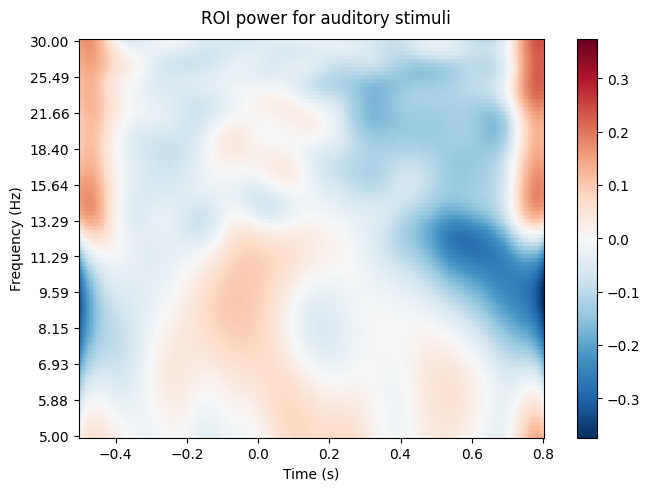

[<Figure size 640x480 with 2 Axes>]

In [5]:
#power.plot_topo(baseline=(-0.5, 0), mode="logratio", title="Average power") 
power_A.plot(picks=roi_channels, baseline=(-0.5, 0), mode="logratio", combine='mean', title='ROI power for auditory stimuli')

In [26]:
epochs_A

<EpochsFIF | 120 events (all good), -0.5 – 0.801 s (baseline -0.2 – 0 s), ~44.7 MiB, data loaded,
 'A': 120>

### V

In [6]:
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']

freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0  # different number of cycle per frequency
power_V = epochs_V.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    decim=3,
    picks=roi_channels
)

Applying baseline correction (mode: logratio)


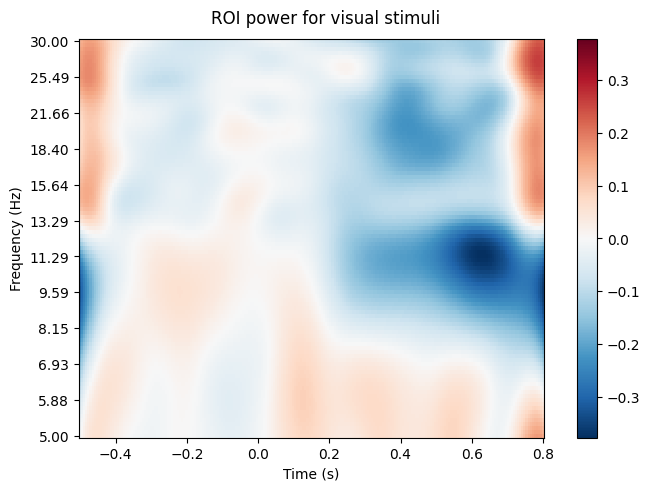

[<Figure size 640x480 with 2 Axes>]

In [7]:
power_V.plot(picks=roi_channels, baseline=(-0.5, 0), mode="logratio", combine='mean', title='ROI power for visual stimuli')

### AV

In [8]:
roi_channels = ['CP1', 'CP3', 'P1', 'P3', 'P5']

freqs = np.logspace(*np.log10([5, 30]), num=100)
n_cycles = freqs / 2.0  # different number of cycle per frequency
power_AV = epochs_AV.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    decim=3,
    picks=roi_channels
)

Applying baseline correction (mode: logratio)


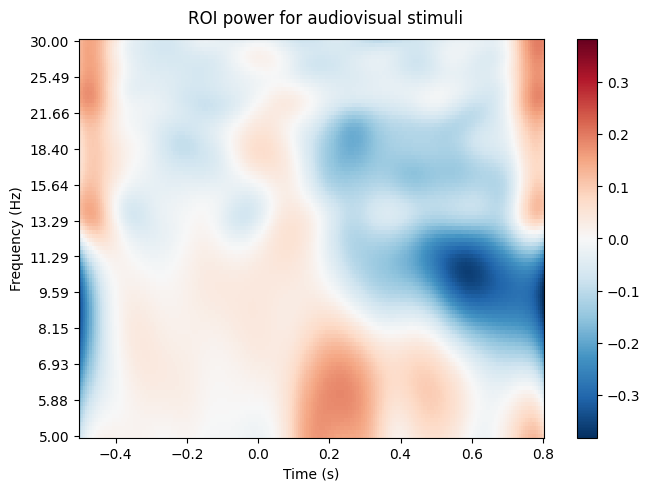

[<Figure size 640x480 with 2 Axes>]

In [9]:
power_AV.plot(picks=roi_channels, baseline=(-0.5, 0), mode="logratio", combine='mean', title='ROI power for audiovisual stimuli')

### MSI effect

In [10]:
power_AV_minus_A = power_AV - power_A

Applying baseline correction (mode: logratio)


/home/p2894/mne_eeg_workshop/.venv/lib/python3.12/site-packages/mne/baseline.py:115: RuntimeWarning: invalid value encountered in log10
  np.log10(d, out=d)


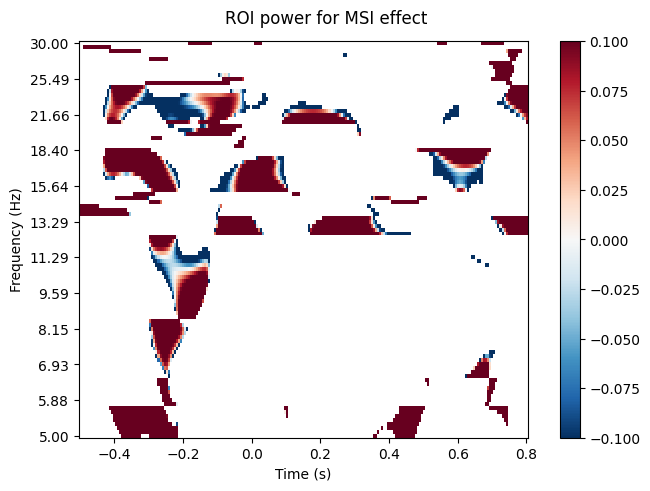

[<Figure size 640x480 with 2 Axes>]

In [11]:
power_AV_minus_A.plot(picks=roi_channels, baseline=(-0.5, 0), mode="logratio", combine='mean', title='ROI power for MSI effect')

Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)


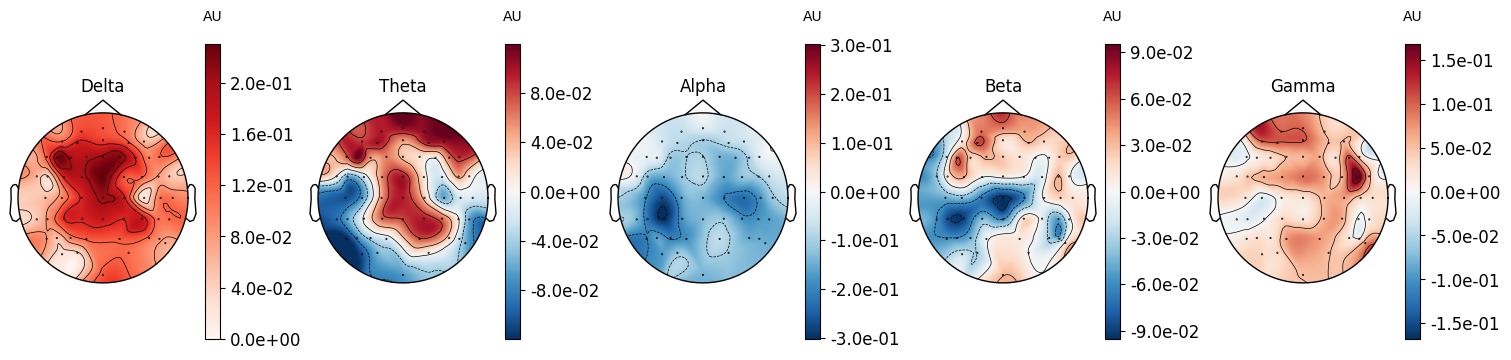

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5), layout="constrained")
topomap_kw = dict(
    ch_type="eeg", tmin=0.5, tmax=1.5, baseline=(-0.5, 0), mode="logratio", show=False
)
plot_dict = dict(Delta=dict(fmin=1, fmax=4), Theta=dict(fmin=4, fmax=8), Alpha=dict(fmin=8, fmax=12), Beta=dict(fmin=13, fmax=30), Gamma=dict(fmin=30, fmax=40))
for ax, (title, fmin_fmax) in zip(axes, plot_dict.items()):
    power.plot_topomap(**fmin_fmax, axes=ax, **topomap_kw)
    ax.set_title(title)

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


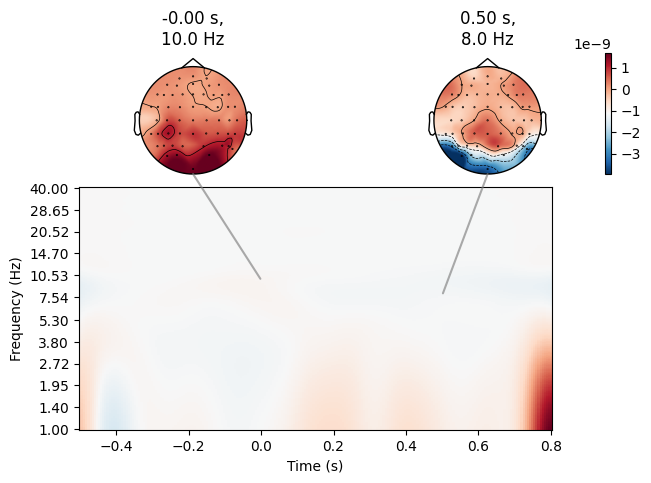

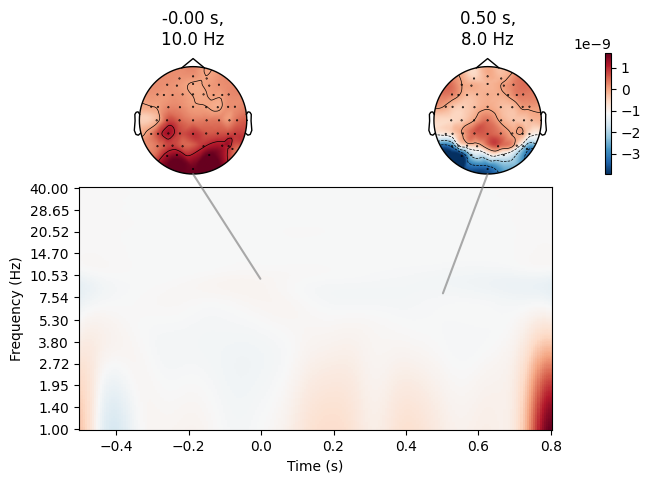

In [19]:
power.plot_joint(
    baseline=(-0.5, 0), mode="mean", tmin=-0.5, tmax=2, timefreqs=[(0, 10), (0.5, 8)]
)

In [ ]:
# Time-frequency analysis for each quartile 
freqs = np.linspace(*np.array([2, 40]), num=200) #num = step / bin allows a precision of the frequency resolution
n_cycles = freqs / 2  # different number of cycle per frequency
    
# Total power for each quartile
power_A = mne.time_frequency.tfr_morlet(epochs_A, freqs=freqs, n_cycles=n_cycles, use_fft=True,
                            output = 'complex', return_itc=False, decim=1, n_jobs=1, average=False)
# Compute Time-Frequency Representation (TFR) using Morlet wavelets, which operates on Epochs or Evoked objects instead of NumPy arrays.
# https://mne.tools/stable/generated/mne.time_frequency.tfr_morlet.html